In [53]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
import shap
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score, mean_absolute_error,median_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.linear_model import LassoCV, ElasticNetCV, RidgeCV # https://scikit-learn.org/stable/api/sklearn.linear_model.html

In [16]:
# FUNCIONES
## Formato 5 decimales
pd.options.display.float_format = '{:,.5f}'.format 

## Mediana del error porcentual
def median_absolute_percentage_error(y_true, y_pred):
    return np.abs((y_true-y_pred)/y_true).median()*100

## Metricas de clasificacion
def metricas_reg(yhat, y_test, yhat_train, y_train):
  metrics_train = r2_score(y_train, yhat_train),mean_absolute_error(y_train, yhat_train),mean_absolute_percentage_error(y_train, yhat_train)*100,median_absolute_error(y_train, yhat_train),median_absolute_percentage_error(y_train, yhat_train)
  metrics_test = r2_score(y_test, yhat),mean_absolute_error(y_test, yhat),mean_absolute_percentage_error(y_test, yhat)*100,median_absolute_error(y_test, yhat),median_absolute_percentage_error(y_test, yhat)
  metrics_diff = list(map(lambda x: x[1]-x[0], zip(metrics_train, metrics_test)))
  return pd.DataFrame(data=[metrics_train, metrics_test, metrics_diff], columns=['R2', 'MAE', 'MAPE', 'Med AE', 'Med APE'], index=['Train set', 'Test set', 'Diferencia'])

#Selección del método de escalado
def escalado(X):
    from scipy.stats import skew, kurtosis
    import pandas as pd

    #Valores estadísticos
    med=list(X.mean())##Media
    cv=list(X.std()/X.mean()*100)#Coeficiente variacion
    men=list(X.quantile(0.5))#Mediana

    #Asimetría
    asim=list(skew(X))
    ##Análisis valores
    asim_an=[]
    for x in asim:
        if x>-0.5 and x<0.5: #Simétria
            asim_an.append("Simétrica")
        elif x<-1 or x>1: #Asimétria alta
            asim_an.append("Asimétrica alta")
        else: #Asimetría moderada
            asim_an.append("Asimétrica moderada")
    
    #Curtosis
    cur=list(kurtosis(X))

    #Análisis
    cur_an=[]
    ##Análisis valores
    for x in cur:
        if x>-0.5 and x<0.5: #Normal
            cur_an.append("Mesocúrtica")
        elif x<-1 or x>1: # Dist. Plana
            cur_an.append("Platicúrtica")
        else: #Peso importante colas y reisgo de outliers
            cur_an.append("Leptocúrtica")

    #Método de escalado
    esc=[]
    #Recorremos variables
    for asi,cu in zip(asim_an, cur_an):
        if asi=="Simétrica":
            if cu=="Leptocúrtica" or cu=="Mesocúrtica":  #Standar scaler
                esc.append("StandardScaler")
            else: #Robust scaler
                esc.append("RobustScaler")
        else: #Robust scaler
            esc.append("RobustScaler")

    return pd.DataFrame([med, men, cv, asim, asim_an, cur, cur_an, esc], 
             columns=X.columns, 
             index=["Media", "Mediana", "Coef. Var.", "Asimetría", "Asimetría Int.", "Curtosis", "Curtosis Int.", "Escalado"]).T

# **0. CONTEXTO Y CARGA DATOS**

**Fuente**: https://github.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/blob/main/README.es.md

**Objetivo**:

Estudiar la relación existente entre la proporción de enfermedades (``anycondition_prevalence``) por condado y los datos socio demográficos y de recursos de salud por condado en los Estados Unidos entre los años 2018 y 2019.

In [17]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/main/demographic_health_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


In [18]:
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.20661,7637,13.73536,6878,12.37028,7089,12.74977,...,3644,12.90000,11.90000,13.80000,5462,3.10000,2.90000,3.30000,1326,3
1,1003,218022,24757,11.35528,26913,12.34417,23579,10.81496,25213,11.56443,...,14692,12.00000,11.00000,13.10000,20520,3.20000,3.00000,3.50000,5479,4
2,1005,24881,2732,10.98027,2960,11.89663,3268,13.13452,3201,12.86524,...,2373,19.70000,18.60000,20.60000,3870,4.50000,4.20000,4.80000,887,6
3,1007,22400,2456,10.96429,2596,11.58929,3029,13.52232,3113,13.89732,...,1789,14.10000,13.20000,14.90000,2511,3.30000,3.10000,3.60000,595,2
4,1009,57840,7095,12.26660,7570,13.08783,6742,11.65629,6884,11.90180,...,4661,13.50000,12.60000,14.50000,6017,3.40000,3.20000,3.70000,1507,2


# **1. ANÁLISIS DE DATOS DESCRIPTIVO** (ADD)

## 1.1. Limpieza de datos

### 1.1.1. Valores únicos

In [19]:
# Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Valores duplicados

In [20]:
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

No hay filas duplicadas


In [21]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

Hay 0 variables exactamente iguales


### 1.1.3. Variables redundantes

In [63]:
#Definimos variables redundantes
redundantes=["0-9", "19-Oct", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+", 
             "White-alone pop", "Black-alone pop", "Native American/American Indian-alone pop", "Asian-alone pop", "Hawaiian/Pacific Islander-alone pop", "Two or more races pop", 
             "POP_ESTIMATE_2018", "Less than a high school diploma 2014-18","High school diploma only 2014-18","Some college or associate's degree 2014-18","Bachelor's degree or higher 2014-18",
             "POVALL_2018", "Obesity_Lower 95% CI", "Obesity_Upper 95% CI", "COUNTY_NAME", 
             "anycondition_Lower 95% CI", "anycondition_Upper 95% CI","anycondition_prevalence","Obesity_prevalence","Obesity_Lower 95% CI","Obesity_Upper 95% CI","Obesity_number","Heart disease_prevalence","Heart disease_Lower 95% CI","Heart disease_Upper 95% CI","Heart disease_number","COPD_prevalence","COPD_Lower 95% CI","COPD_Upper 95% CI","COPD_number","diabetes_prevalence","diabetes_Lower 95% CI","diabetes_Upper 95% CI","diabetes_number","CKD_prevalence","CKD_Lower 95% CI","CKD_Upper 95% CI","CKD_number", "STATE_NAME"]

df.drop(columns=redundantes, inplace=True)
print(f"{len(redundantes)} filas no importantes eliminadas")

KeyError: '[\'0-9\', \'19-Oct\', \'20-29\', \'30-39\', \'40-49\', \'50-59\', \'60-69\', \'70-79\', \'80+\', \'White-alone pop\', \'Black-alone pop\', \'Native American/American Indian-alone pop\', \'Asian-alone pop\', \'Hawaiian/Pacific Islander-alone pop\', \'Two or more races pop\', \'POP_ESTIMATE_2018\', \'Less than a high school diploma 2014-18\', \'High school diploma only 2014-18\', "Some college or associate\'s degree 2014-18", "Bachelor\'s degree or higher 2014-18", \'POVALL_2018\', \'Obesity_Lower 95% CI\', \'Obesity_Upper 95% CI\', \'COUNTY_NAME\', \'anycondition_Lower 95% CI\', \'anycondition_Upper 95% CI\', \'anycondition_prevalence\', \'Obesity_prevalence\', \'Obesity_Lower 95% CI\', \'Obesity_Upper 95% CI\', \'Obesity_number\', \'Heart disease_prevalence\', \'Heart disease_Lower 95% CI\', \'Heart disease_Upper 95% CI\', \'Heart disease_number\', \'COPD_prevalence\', \'COPD_Lower 95% CI\', \'COPD_Upper 95% CI\', \'COPD_number\', \'diabetes_prevalence\', \'diabetes_Lower 95% CI\', \'diabetes_Upper 95% CI\', \'diabetes_number\', \'CKD_prevalence\', \'CKD_Lower 95% CI\', \'CKD_Upper 95% CI\', \'CKD_number\'] not found in axis'

### 1.1.4. Valores faltantes

In [23]:
#Mostramos columnas con valores nulos
nulos=df.isna().sum()/len(df)*100
nulos[nulos>0.1]

Series([], dtype: float64)

[]

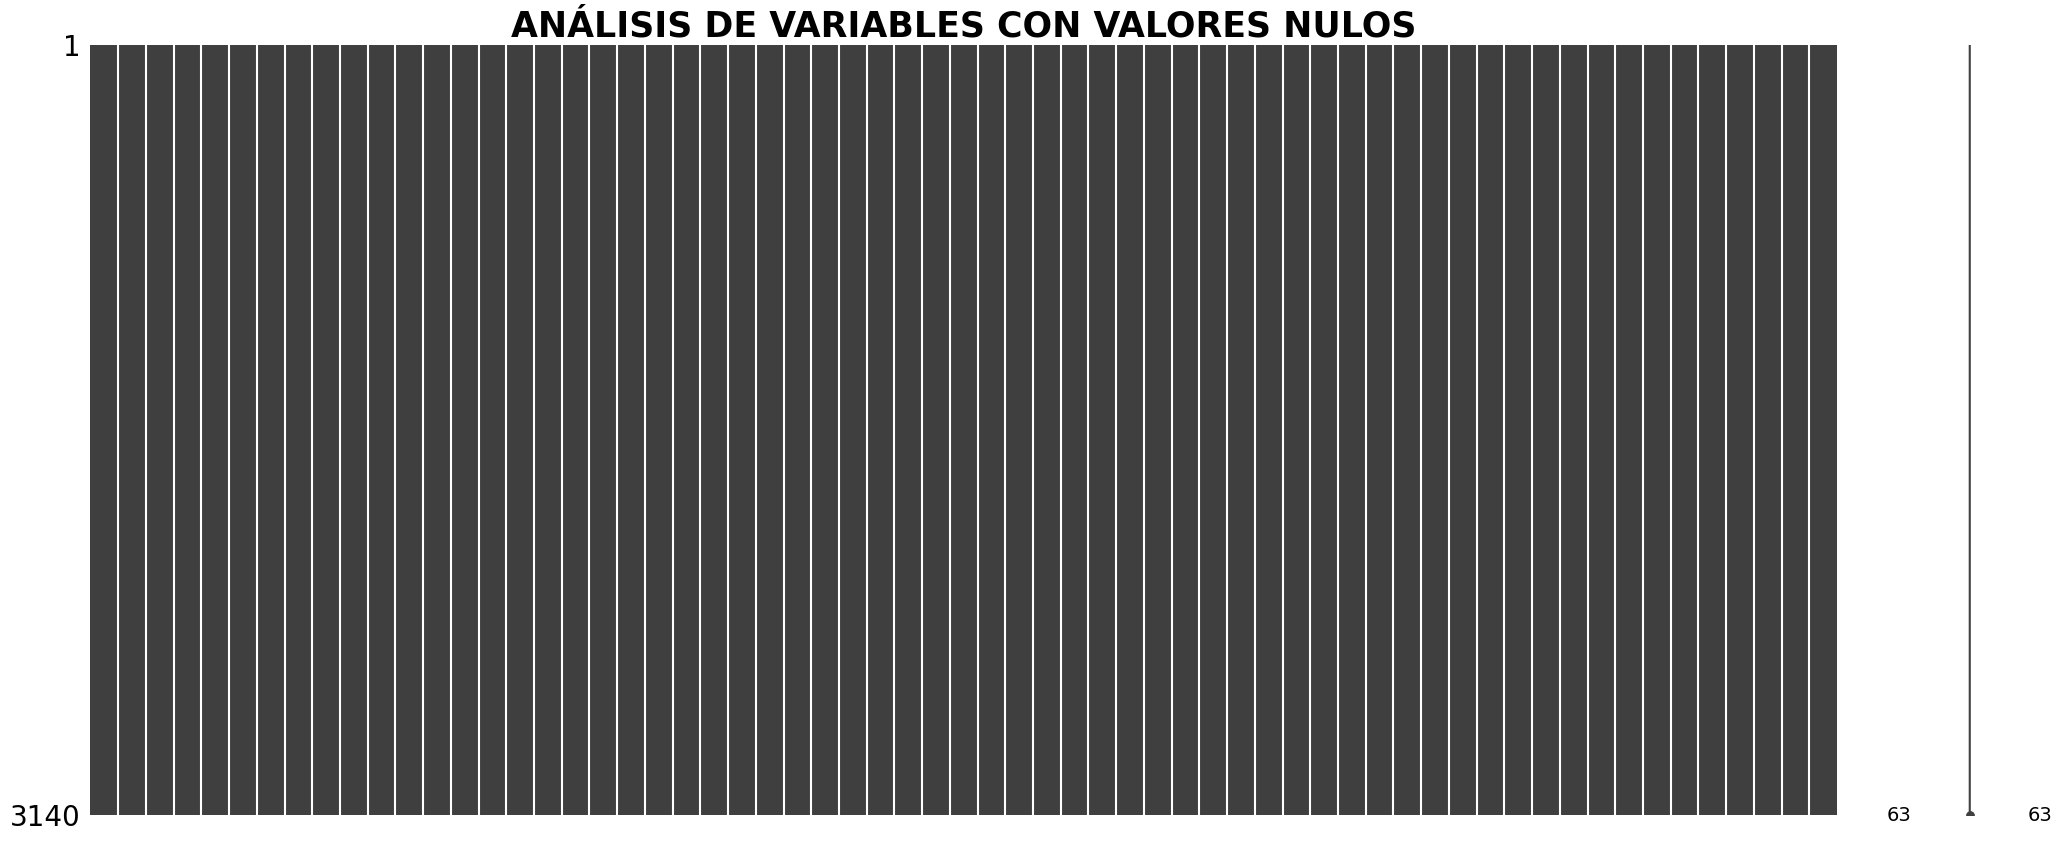

In [24]:
#Gráficamente
msno.matrix(df)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.plot()

No tenemos valores faltantes en nuestra base de datos.

## 1.2. Análisis Univariante

### A) Target

In [25]:
df["anycondition_number"].describe()

count       3,140.00000
mean       33,385.39968
std        98,886.68985
min            41.00000
25%         4,215.00000
50%         9,753.00000
75%        25,001.25000
max     2,877,316.00000
Name: anycondition_number, dtype: float64

La variable objetivo de estudio va a ser el numero de personas con algun tipo de enfermedad: obsesidad, diabetes, enfermedad cardíaca, pulmonar o renal.

# **2. ANÁLISIS EXPLORATORIO DE DATOS** (AED)

## 2.1. Train-test split

In [34]:
df_train, df_test=train_test_split(df, test_size=0.2, random_state=42)

-----

# **2. SELECCIÓN DE CARACTERÍSTICAS**

## 2.1. Aplicar métodos

### 2.1.1. Feature Importance

In [ ]:
# Entrenamiento de RF
model = RandomForestRegressor(random_state=42,n_jobs=-1).fit(X_train, y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Mostramos resultados
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
df_rf_imp

,feature,rf_importance
4,smoker,43.97574
0,age,37.36620
1,bmi,10.27558
2,children,5.07968
3,male,1.14449
6,southeast,0.85884
5,northwest,0.75324
7,southwest,0.54623


### 2.1.2. Permutation Importance

In [ ]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
# Entrenamos el modelo que va a porporcionarnos las predicciones por cada alteracion
model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42).fit(X_train1, y_train1)
# Intanciamos permitation forest
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='neg_mean_absolute_error')
## Extraemos los valores a un df
df_perm_imp = pd.DataFrame({'feature': X_train1.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
0,age,38.59704
4,smoker,37.21585
2,children,7.58528
1,bmi,2.95002
3,male,0.85534
7,southwest,0.84001
6,southeast,0.55656
5,northwest,0.33308


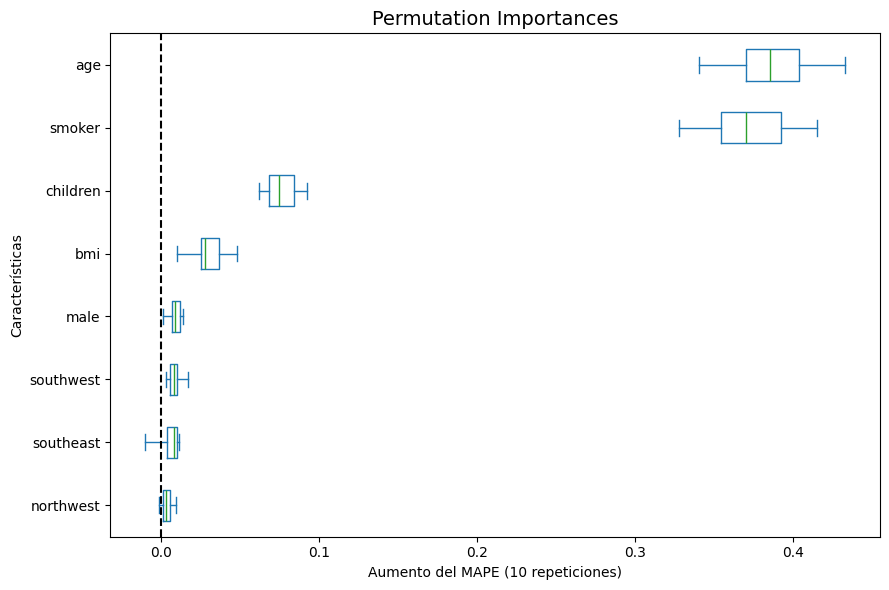

In [ ]:
# REPRESENTACIÓN GRÁFICA
## Orden de las variables (de menor a mayor importancia media):
### - asegura que el gráfico final esté ordenado
sorted_idx = perm.importances_mean.argsort()

## DataFrame para el Box Plot
### - perm.importances devuelve los n cambios en f1 de la caract x 
importances_df = pd.DataFrame(
    perm.importances[sorted_idx].T,
    columns=X_train.columns[sorted_idx] 
)
importances_df

## Gráfico
fig, ax = plt.subplots(figsize=(9,6))

### Usamos .plot.box() directamente sobre el DataFrame (columna por columna)
ax = importances_df.plot.box(vert=False, whis=10, ax=ax) # vert=False -> gráfico horizontal
ax.set_title("Permutation Importances", fontsize=14)
ax.set_ylabel("Características")
ax.axvline(x=0, color="k", linestyle="--") # Línea vertical en 0 (sin ganancia/pérdida)
ax.set_xlabel("Aumento del MAPE (10 repeticiones)") 
fig.tight_layout()
plt.show()

### 2.1.3. SHAP

In [ ]:
# Ajustamos un modelo predictor para analizar la importancia de cada caract.
model_gbc = GradientBoostingRegressor(random_state=42).fit(X_train1, y_train1) 
# Instanciamos el shap explainer y extraemos los valores
explainer = shap.Explainer(model_gbc, X_val)  
shap_vals = explainer(X_val).values
# Pasamos los valores absolutos a un df
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_train.columns, "shap_imp": imp_shap_pct.round(3)}).sort_values('shap_imp', ascending=False)
df_shap_imp

,feature,shap_imp
4,smoker,37.43900
0,age,36.45700
2,children,10.81300
1,bmi,6.11400
7,southwest,3.33000
3,male,2.80500
6,southeast,2.50100
5,northwest,0.54100


## 2.2. Seleccionar variables

In [ ]:
#Añadimos resultados a un único df
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('perm_imp', ascending=False)

#Mostramos resultado
df_importances

,feature,rf_importance,perm_imp,shap_imp
0,age,37.36620,38.59704,36.45700
5,smoker,43.97574,37.21585,37.43900
2,children,5.07968,7.58528,10.81300
1,bmi,10.27558,2.95002,6.11400
3,male,1.14449,0.85534,2.80500
7,southwest,0.54623,0.84001,3.33000
6,southeast,0.85884,0.55656,2.50100
4,northwest,0.75324,0.33308,0.54100


In [ ]:
# Eliminamos aquellas con un permutation importance negativo
df_sel=df_importances[(df_importances["rf_importance"]>1)&(df_importances["perm_imp"]>1)&(df_importances["shap_imp"]>1)]
df_sel

,feature,rf_importance,perm_imp,shap_imp
0,age,37.36620,38.59704,36.45700
5,smoker,43.97574,37.21585,37.43900
2,children,5.07968,7.58528,10.81300
1,bmi,10.27558,2.95002,6.11400


No vamos a aplicar filtrado en los valores de permutation para ver si ``male`` aporta información estadisiticamente significativa a nuestro modelo de regresión lineal.

In [ ]:
# RESUMEN DE LA SELECCIÓN
## Seleccionados
sel=df_sel["feature"].tolist()
## Eliminados
### -Difference extrae las etiquetas que estan en un index pero no en otra colección
elm=X_train.columns.difference(sel).tolist()

##Condicional para verificar que mostramos todas las columnas
if X_train.shape[1]==(len(sel)+len(elm)):
    # Texto
    print(f"{len(elm)} columnas eliminadas:")
    print(elm)
    print("-"*120)
    print(f"{len(sel)} columnas seleccionadas:")
    print(sel)

else: print("Error al computar las columnas eliminadas")

4 columnas eliminadas:
['male', 'northwest', 'southeast', 'southwest']
------------------------------------------------------------------------------------------------------------------------
4 columnas seleccionadas:
['age', 'smoker', 'children', 'bmi']


## 2.3. Comprobar vif y correlaciones

In [ ]:
## Variable Xi: añdimos cte. para no asumir que regresión pasa por (0,0) y tener problemas con R2 de vif
x_vif=add_constant(X_train[sel])

In [ ]:
# VIF
## Variable Xi: añdimos cte. para no asumir que regresión pasa por (0,0) y tener problemas con R2 de vif
x_vif=add_constant(X_train[sel])

## Cálculo: x_vif.values (array con los datos), i valor de la columna que asuma Yi
vif = pd.Series([variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])], index=x_vif.columns).drop(index="const")
vif[vif>5]

Series([], dtype: float64)

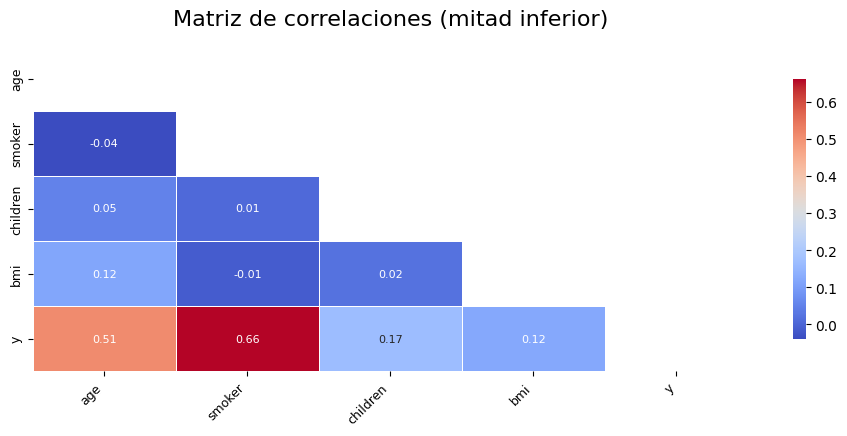

In [ ]:
#Análisis de correlaciones entre regresores
x_vif.drop(columns="const", axis=1, inplace=True)
x_vif['y'] = y_train
corr = x_vif.corr()

#Mapa de correlaciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    corr, mask=np.triu(np.ones_like(corr, dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

De esta forma, podemos afirmar que las variables explicativas del modelo no presentan ningun tipo de colinealidad entre ellas.

# 3. Modelado

## 3.1. Escalado de datos

### 3.1.1. Preprocesamiento

https://scikit-learn.org/stable/api/sklearn.preprocessing.html

In [ ]:
# Definimos características objetivo
## BBDD train
X_train=X_train[sel]
## BBDD test
X_test=X_test[sel]

# Visualizamos resultados
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"1,069.00000",39.26006,13.94155,18.00000,27.00000,39.00000,51.00000,64.00000
smoker,"1,069.00000",0.20393,0.40311,0.00000,0.00000,0.00000,0.00000,1.00000
children,"1,069.00000",1.10103,1.19968,0.00000,0.00000,1.00000,2.00000,5.00000
bmi,"1,069.00000",30.66974,6.06485,15.96000,26.40000,30.30000,34.70000,53.13000


De esta forma, vamos a trabajar en el escalado de todas las variables menos la dummy ``smoker``.

In [ ]:
escalado(X_train.drop(columns="smoker"))

,Media,Mediana,Coef. Var.,Asimetría,Asimetría Int.,Curtosis,Curtosis Int.,Escalado
age,39.26006,39.00000,35.51077,0.06705,Simétrica,-1.21923,Platicúrtica,RobustScaler
children,1.10103,1.00000,108.95950,0.95111,Asimétrica moderada,0.28003,Mesocúrtica,RobustScaler
bmi,30.66974,30.30000,19.77472,0.31741,Simétrica,-0.00504,Mesocúrtica,StandardScaler


Pese a que bmi presenta una distribución similar a una normal, vamos a aplicar Robust Scaler  pues a nivel general no tienen distribuciones normales.

### 3.1.2. Robust Scaler

In [ ]:
#Instaciamos el escalador
scal=RobustScaler()
##Ajustamos y transformamos para train
train_sc=scal.fit_transform(X_train.drop(columns="smoker")) #no es necesario escalar una variable con una escala cercana a 1 (0/1)
##Solo transformamos para test (independia base datos)
test_sc=scal.transform(X_test.drop(columns="smoker"))

#Pasamos a df
##Columnas
col=X_train.drop(columns="smoker").columns
##Train
X_train_sc=pd.DataFrame(train_sc, columns=col, index=X_train.index)
X_train_sc["smoker"]=X_train["smoker"]
##Test
X_test_sc=pd.DataFrame(test_sc, columns=col, index=X_test.index)
X_test_sc["smoker"]=X_test["smoker"]

In [ ]:
#Testamos el resultado
X_train_sc.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"1,069.00000",0.01084,0.58090,-0.87500,-0.50000,0.00000,0.50000,1.04167
children,"1,069.00000",0.05051,0.59984,-0.50000,-0.50000,0.00000,0.50000,2.00000
bmi,"1,069.00000",0.04455,0.73071,-1.72771,-0.46988,0.00000,0.53012,2.75060
smoker,"1,069.00000",0.20393,0.40311,0.00000,0.00000,0.00000,0.00000,1.00000


## 3.2. Entrenamiento

In [ ]:
# Instanciamos el modelo
reg = LinearRegression()
#Ajustamos en train y aplicamos modelo a test (evitamos dataleakage)
reg.fit(X_train_sc, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 3.2.1. Evaluación predicción

In [ ]:
#Realizamos predicciones en train
y_hat_train=reg.predict(X_train_sc)
#Entrenamos en test y realizamos predicciones
y_hat_test=reg.predict(X_test_sc)
#Analizamos métricas
metricas_reg(np.exp(y_hat_test), np.exp(y_test), np.exp(y_hat_train), np.exp(y_train))

,R2,MAE,MAPE,Med AE,Med APE
Train set,0.50266,"4,291.45259",27.61845,967.44873,13.94059
Test set,0.68284,"3,804.87308",27.29986,"1,015.99189",13.94762
Diferencia,0.18018,-486.57952,-0.31859,48.54316,0.00703


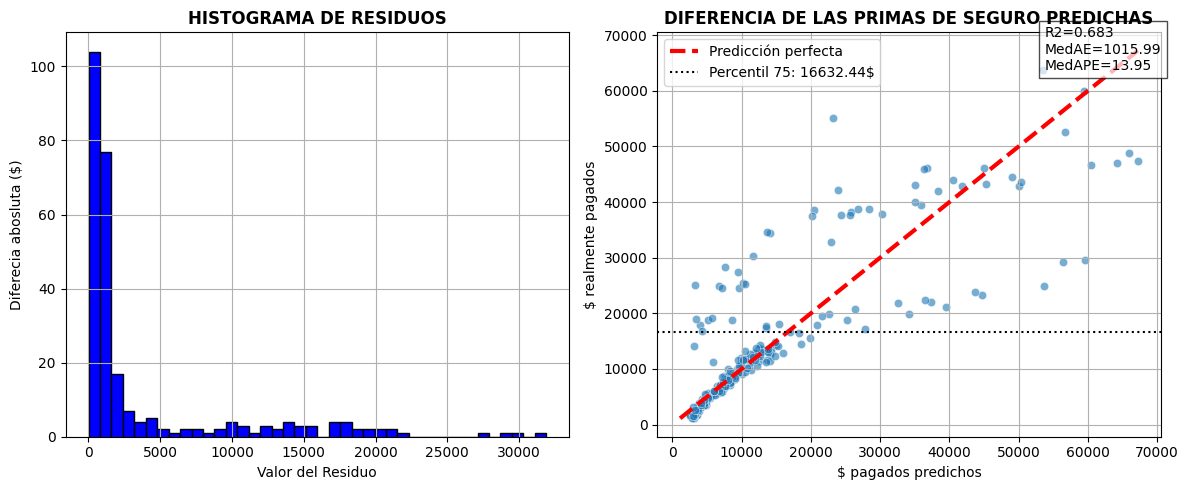

In [ ]:
##Reestablecemos las escalas
y_true = np.exp(y_test)
y_pred = np.exp(y_hat_test)
residuos=y_true-y_pred
##Valores a representar
r2  = r2_score(y_true, y_pred)
medae = median_absolute_error(y_true, y_pred)
medape = median_absolute_percentage_error(y_true, y_pred)

# Crea una figura con dos subgráficos (uno para el histograma y otro la comparación de las predicciones)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
ax1.hist(np.abs(residuos), bins=40, color='blue', edgecolor='black')
ax1.set_title('Histograma de Residuos'.upper(), fontweight="bold")
ax1.set_xlabel('Valor del Residuo')
ax1.set_ylabel('Diferecia abosluta ($)')
ax1.grid(True)

# Nube de puntos
##Linea identidad: trazamos una linea para la cual los valores sería iguales (ajuste perfecto)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
sns.scatterplot(y=y_true, x=y_pred, ax=ax2, alpha=0.6)
ax2.plot(lims, lims, 'k--', linewidth=3, color="red", label="Predicción perfecta")
ax2.axhline(y_true.quantile(0.75),linestyle=':',color="black", label=f"Percentil 75: {y_true.quantile(0.75).round(2)}$")
ax2.set_title("Diferencia de las primas de seguro predichas".upper(), fontweight="bold")
ax2.set_ylabel('$ realmente pagados')
ax2.set_xlabel('$ pagados predichos')
ax2.grid(True)
ax2.legend()
ax2.text(y_true.max()-10000, y_true.max(), f"R2={r2:.3f}\nMedAE={medae:.2f}\nMedAPE={medape:.2f}", bbox=dict(facecolor='white', alpha=0.7))

# Muestra la figura con ambos gráficos
plt.tight_layout()  # Ajusta los márgenes para evitar superposiciones
plt.show()

El modelo entrenado tiene un desempeño superior en la base de datos de prueba, de forma que llega a explicar el 68,28% de la variabilidad total de los valores de prima de seguro observadas. 

Consecuentemente, el error mediano de las predicciones es de 1016 dólares, esto es, hemos desarrollado un modelo cuyo error porcentual promedio es del 27,3%. 

No obstante, la gran mayoría de dicho error se concentra en primas ciertamente "extremas", concretamente por encima del percentil 75 (16632,44$) de las primas de prueba, lo cual hace que la mediana del error porcentual del modelo descienda hasta un 13,95. Esto es un indicador de heterocedasticidad, es decir, el error de la predicción varía con la magnitud. 

### 3.2.2. Análisis coeficientes

En este caso, desharemos los cambios de escala realizados en los regresores para poder interpretar sus coeficientes y residuos.

In [ ]:
#Entrenamos y ajustamos el modelo con los datos de prueba
model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     803.9
Date:                Fri, 05 Dec 2025   Prob (F-statistic):          1.06e-319
Time:                        12:52:40   Log-Likelihood:                -668.60
No. Observations:                1069   AIC:                             1347.
Df Residuals:                    1064   BIC:                             1372.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0313      0.079     88.885      0.0

ANÁLISIS DE RESULTADOS

Omnibus &rarr; test de normalidad (asimetria y curtosis)

    - p=0; residuos no normales

Jarque-Bera &rarr; test de normalidad

    - p=0; residuos no normales

Durbin-Watson &rarr; test de autocorrelación

    - DW=2; no autocorrelacción

Número de condición &rarr; multicolinealidad/escalado

    - CN>30; implementar escalado

In [ ]:
betas=model.params[1:]*100
print(f"- Si la edad del individuo se incrementa en un año, su gasto en seguro médico aumenta un {betas[0].round(2)}%")
print(f"- El gasto medio en seguro médico es un {betas[1].round(2)}% mayor para los fumadores")
print(f"- El hecho de tener un hijo más hace que el gasto en seguro médico aumente un {betas[2].round(2)}%")
print(f"- El hecho de tener un mayor peso relativo a nuestra altura hace aumentar el gasto en seguro médico en un {betas[0].round(3)}%")

- Si la edad del individuo se incrementa en un año, su gasto en seguro médico aumenta un 3.4%
- El gasto medio en seguro médico es un 153.9% mayor para los fumadores
- El hecho de tener un hijo más hace que el gasto en seguro médico aumente un 10.1%
- El hecho de tener un mayor peso relativo a nuestra altura hace aumentar el gasto en seguro médico en un 3.403%


Desde el punto de vista de las aseguradoras y los hospitales, le es más rentable que la edad media de sus clientes sea alta, que tengan muchos hijos, que sean fumadores y que tengan mucho peso. 

## 3.4. Optimización

Vamos a evaluar si podemos optimizar las predicciones realizando las siguientes regularizaciones:

 - **LASSO (L1)**: es más útil en modelo sobreajustado con un número importante de coeficientes estimados

 - **Ridge (L2)**: es más útil en modelo con multicolinealidad entre sus regresores

 - **ElasticNet**: cubre las dos patas (modelos sobreajustados con multicolinealidad)

In [ ]:
#Definimos los alphas para las penalizaciones
alphas = np.logspace(-4, 4, 50)

In [ ]:
#Intanciamos Lasso CV
lasso_cv = LassoCV(alphas=alphas, cv=5, n_jobs=-1, random_state=42, max_iter=10000)
##Entrenamiento
lasso_cv.fit(X_train_sc, y_train)
##Predicciones
trainhat_l1=lasso_cv.predict(X_train_sc)
testhat_l1=lasso_cv.predict(X_test_sc)

In [ ]:
#Intanciamos Ridge CV
ridge_cv = RidgeCV(alphas=alphas, cv=5)
##Entrenamiento
ridge_cv.fit(X_train_sc, y_train)
##Predicciones
trainhat_l2=ridge_cv.predict(X_train_sc)
testhat_l2=ridge_cv.predict(X_test_sc)

In [ ]:
#Intanciamos ElasticNet CV
l1_grid = np.linspace(0.1, 0.9, 9)  # l1_ratio
en_cv = ElasticNetCV(alphas=alphas, l1_ratio=l1_grid, cv=5, n_jobs=-1, random_state=42, max_iter=10000)
##Entrenamiento
en_cv.fit(X_train_sc, y_train)
##Predicciones
trainhat_en=en_cv.predict(X_train_sc)
testhat_en=en_cv.predict(X_test_sc)

In [ ]:
#Metricas para cada modelo
print("-"*50)
print("Modelo sin regularizar")
print("-"*50)
print(metricas_reg(np.exp(y_hat_test), np.exp(y_test), np.exp(y_hat_train), np.exp(y_train)))
print("-"*50)
print("Modelo con regularización L1")
print("-"*50)
print(metricas_reg(np.exp(testhat_l1), np.exp(y_test), np.exp(trainhat_l1), np.exp(y_train)))
print("-"*50)
print("Modelo con regularización L2")
print("-"*50)
print(metricas_reg(np.exp(testhat_l2), np.exp(y_test), np.exp(trainhat_l2), np.exp(y_train)))
print("-"*50)
print("Modelo con regularización EslaticNet")
print("-"*50)
print(metricas_reg(np.exp(testhat_en), np.exp(y_test), np.exp(trainhat_en), np.exp(y_train)))

--------------------------------------------------
Modelo sin regularizar
--------------------------------------------------
             R2     MAE  MAPE  Med AE  Med APE
Train set  0.50 4291.45 27.62  967.45    13.94
Test set   0.68 3804.87 27.30 1015.99    13.95
Diferencia 0.18 -486.58 -0.32   48.54     0.01
--------------------------------------------------
Modelo con regularización L1
--------------------------------------------------
             R2     MAE  MAPE  Med AE  Med APE
Train set  0.50 4283.99 27.62  968.08    13.88
Test set   0.68 3802.00 27.32 1018.53    13.89
Diferencia 0.18 -481.99 -0.30   50.45     0.00
--------------------------------------------------
Modelo con regularización L2
--------------------------------------------------
             R2     MAE  MAPE  Med AE  Med APE
Train set  0.51 4282.68 27.63  974.29    13.92
Test set   0.68 3800.49 27.33 1018.67    13.95
Diferencia 0.18 -482.19 -0.31   44.38     0.04
-------------------------------------------------

El hecho de tener un escaso número de regresores, hace que las regularizaciones practicamente no tengan efecto